CUSTOMER BEHAVIOURS ANALYSIS AND BUSINESS DECISION MAKING

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

section:1 data understanding

In [3]:
df = pd.read_csv('Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df.shape

(200, 5)

In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [8]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

SECTION 2: DESCRIPTIVE ANALYSIS

In [11]:
print('mean:', df['Age'].mean())
print('median:', df['Age'].median())
print('mode:', df['Age'].mode().iloc[0])

mean: 38.85
median: 36.0
mode: 32


In [12]:
print('mean:',df['Annual Income (k$)'].mean())
print('median:',df['Annual Income (k$)'].median())
print('mode:',df['Annual Income (k$)'].mode().iloc[0])

mean: 60.56
median: 61.5
mode: 54


In [13]:
print('mean:', df['Spending Score (1-100)'].mean(0))
print('median:', df['Spending Score (1-100)'].median(0))
print('mode:', df['Spending Score (1-100)'].mode().iloc[0])

mean: 50.2
median: 50.0
mode: 42


SECTION 3: VISUALIZATION

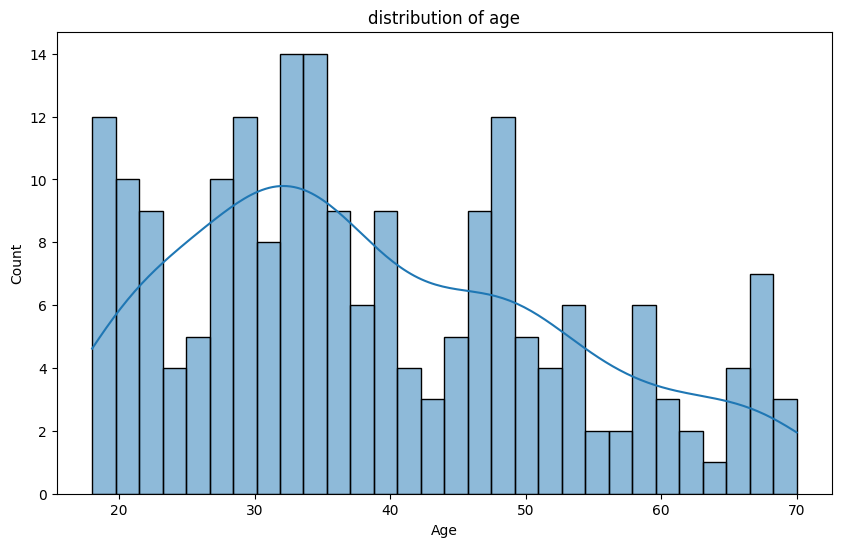

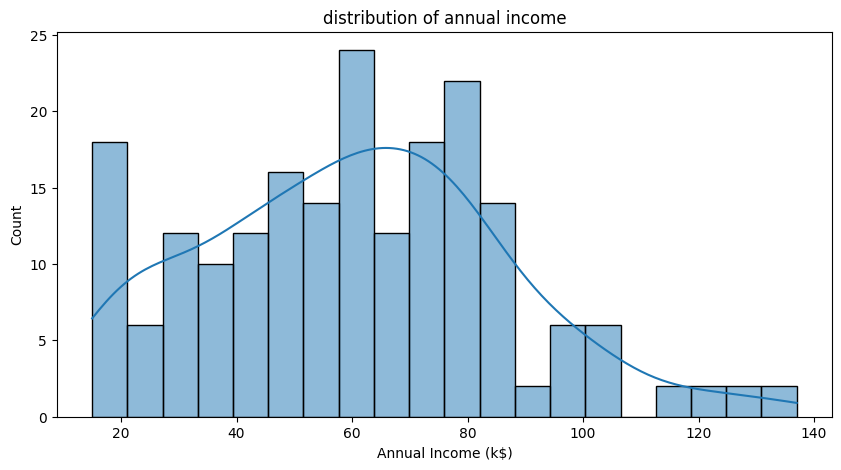

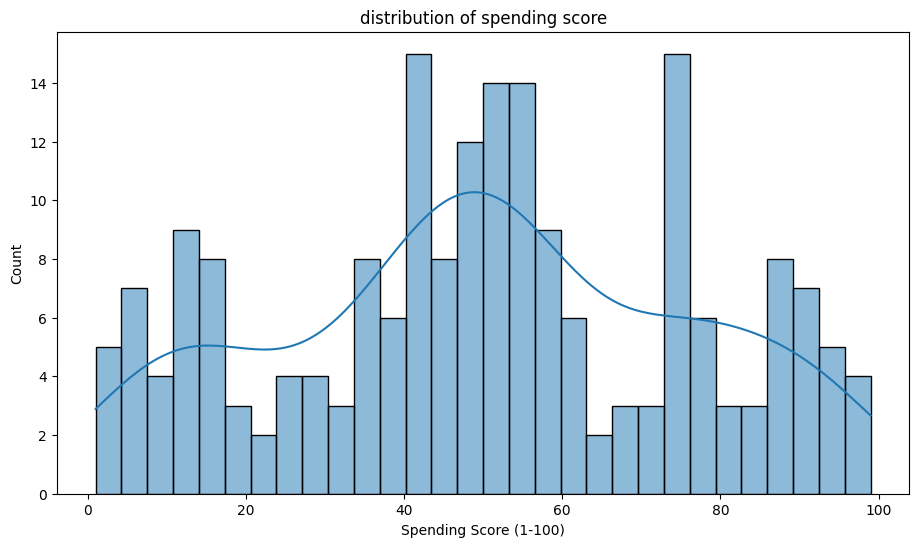

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df['Age'],bins=30, kde=True)
plt.title('distribution of age')
plt.figure(figsize=(10,5))
sns.histplot(df['Annual Income (k$)'],bins=20,kde=True)
plt.title('distribution of annual income')
plt.figure(figsize=(11,6))
sns.histplot(df['Spending Score (1-100)'],bins=30,kde=True)
plt.title('distribution of spending score')
plt.show()


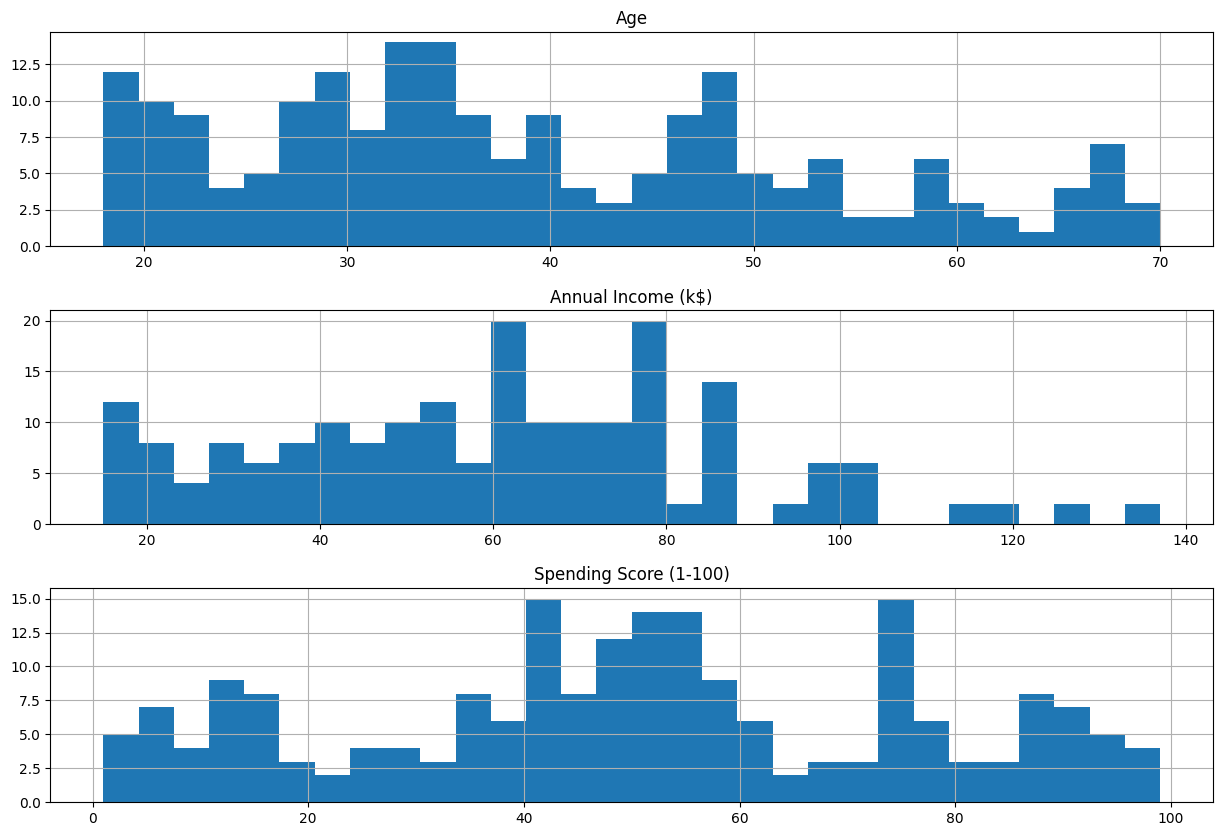

In [15]:
df.hist(column=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], bins=30, figsize=(15,10), layout=(3,1))
plt.show()

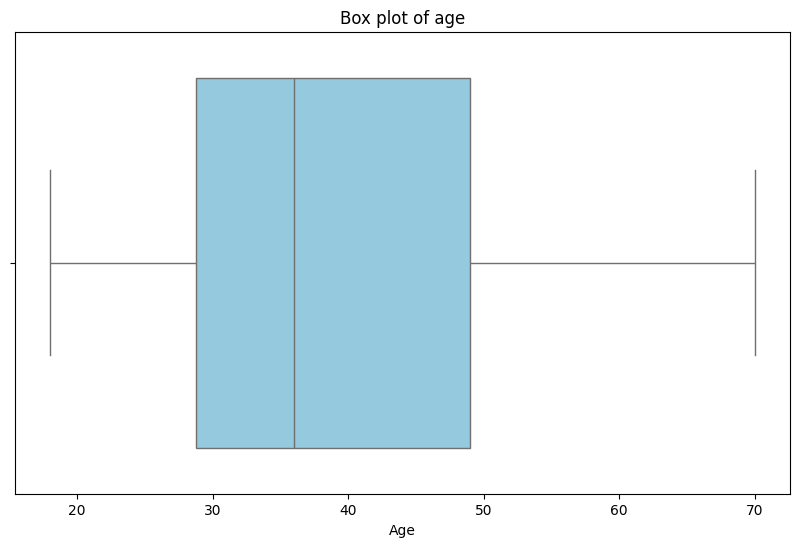

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Age', data=df, color='skyblue')
plt.title('Box plot of age')
plt.xlabel('Age')

plt.show()

In [21]:
q1 = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]
print(f"Total outliers in age : {len(outliers)}")
outliers.head()

Total outliers in age : 0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


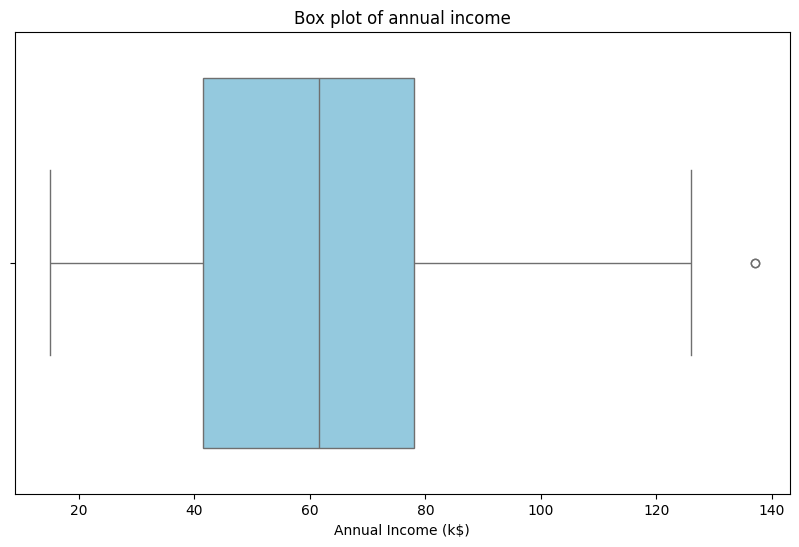

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Annual Income (k$)', data=df, color='skyblue')
plt.title('Box plot of annual income')
plt.xlabel('Annual Income (k$)')

plt.show()

In [22]:
q1 = df['Annual Income (k$)'].quantile(0.25)
q3 = df['Annual Income (k$)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
outliers = df[(df['Annual Income (k$)'] < lower_bound) | (df['Annual Income (k$)'] > upper_bound)]
print(f"Total outliers in annual income : {len(outliers)}")
outliers.head()

Total outliers in annual income : 2


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
198,199,Male,32,137,18
199,200,Male,30,137,83


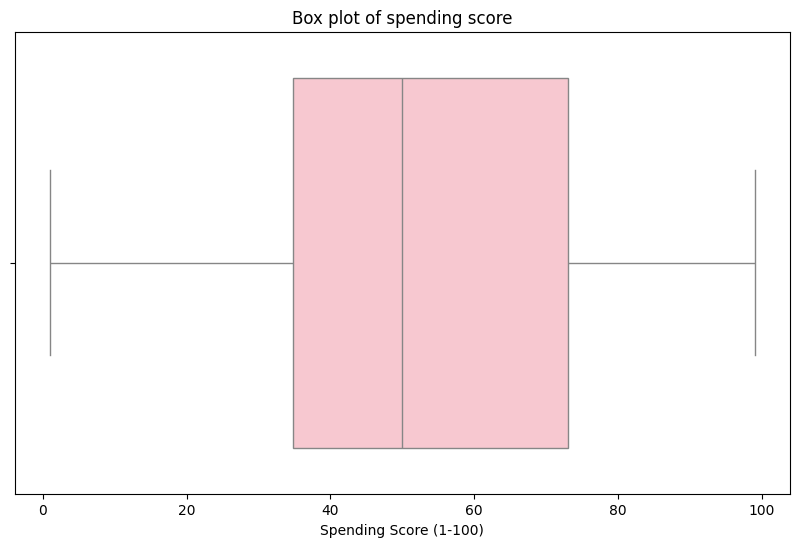

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Spending Score (1-100)', data=df, color='pink')
plt.title('Box plot of spending score')
plt.xlabel('Spending Score (1-100)')

plt.show()

In [23]:
q1 = df['Spending Score (1-100)'].quantile(0.25)
q3 = df['Spending Score (1-100)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
outliers = df[(df['Spending Score (1-100)'] < lower_bound) | (df['Spending Score (1-100)'] > upper_bound)]
print(f"Total outliers in spending score : {len(outliers)}")
outliers.head()

Total outliers in spending score : 0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


SECTION 4: GROUP - BASED ANALYSIS

In [25]:
gender_analysis = df.groupby('Gender')[['Annual Income (k$)','Spending Score (1-100)']].mean()
print(gender_analysis)

        Annual Income (k$)  Spending Score (1-100)
Gender                                            
Female           59.250000               51.526786
Male             62.227273               48.511364


In [26]:
average_Income = np.mean(df['Annual Income (k$)'])
average_Spending_Score = np.mean(df['Spending Score (1-100)'])
print(f"Average Annual Income:{average_Income}")
print(f"Average Spending Score:{average_Spending_Score}")

Average Annual Income:60.56
Average Spending Score:50.2


In [30]:
analysis_named = df.groupby('Gender').agg(average_Income=('Annual Income (k$)', 'mean'), average_Spending_Score=('Spending Score (1-100)', 'mean'))
print(analysis_named)

        average_Income  average_Spending_Score
Gender                                        
Female       59.250000               51.526786
Male         62.227273               48.511364


SECTION 5: CORRELATION ANALYSIS

In [33]:
corr_age_spending_score = df['Age'].corr(df['Spending Score (1-100)'])
print(f"correlation between age and spending score:{corr_age_spending_score}")
corr_annual_income_spending_score = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])
print(f"correlation between annual income and spending score:{corr_annual_income_spending_score}")

correlation between age and spending score:-0.32722684603909
correlation between annual income and spending score:0.009902848094037606


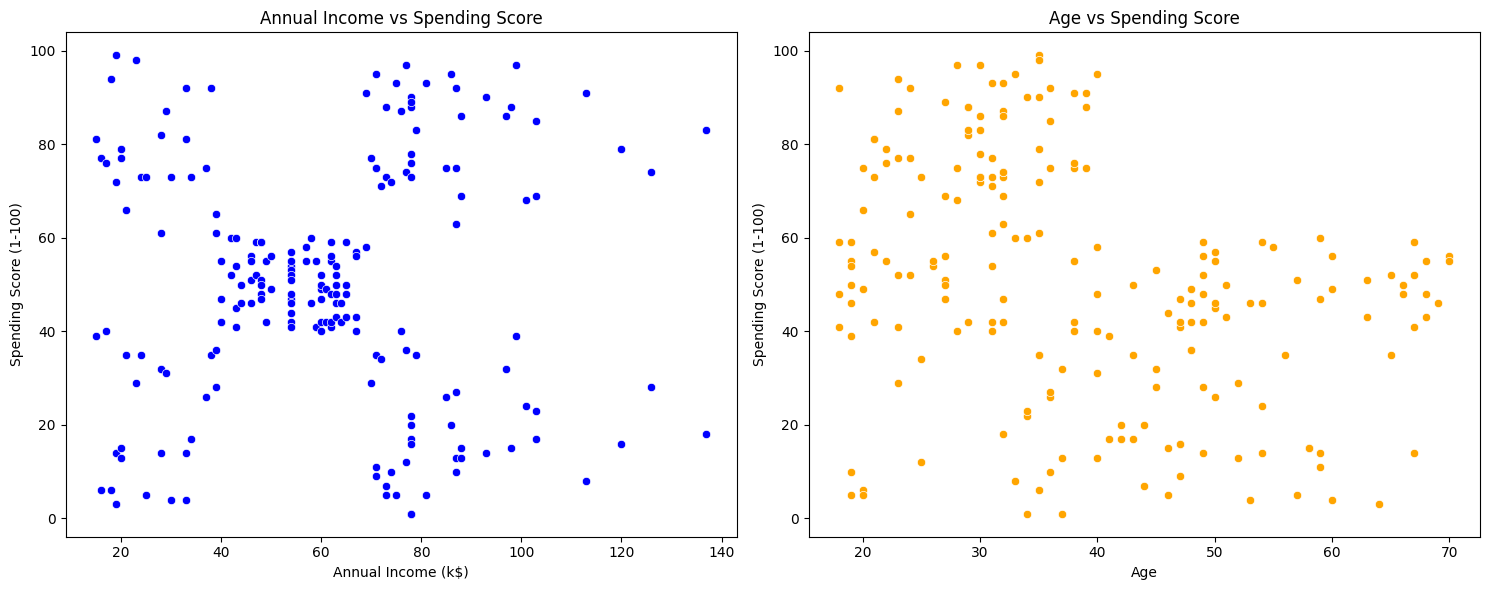

In [35]:
fig, axes = plt.subplots(1,2,figsize=(15,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, ax=axes[0], color='blue')
axes[0].set_title('Annual Income vs Spending Score')
sns.scatterplot(x='Age', y='Spending Score (1-100)', data=df, ax=axes[1], color='orange')
axes[1].set_title('Age vs Spending Score')
plt.tight_layout()
plt.show()

SECTION 6: INFERENTIAL STATISTIC(CORE)

In [36]:
print('problem statement:Do male and female customers spend differently?')
print('Step 1: Hypothesis testing')
print(' H_0: There is no significant difference in spending scores between genders')
print(' H_1: There is a significant difference in spending scores between genders')

problem statement:Do male and female customers spend differently?
Step 1: Hypothesis testing
 H_0: There is no significant difference in spending scores between genders
 H_1: There is a significant difference in spending scores between genders


In [39]:
male = df[df['Gender'] == 'Male']['Spending Score (1-100)']
female = df[df['Gender'] == 'Female']['Spending Score (1-100)']
t_stat, p_value = stats.ttest_ind(male,female)
print(f"t-statistic:{t_stat}")
print(f"pvalue:{p_value}")


t-statistic:-0.8190464150660334
pvalue:0.4137446589852174


 since p_value (0.4137446589852174) is greater than or equal to alpha (0.05), we fail to reject the null hypothesis.
 Conclusion:  there is no statistically significant difference in spending scores bewteen genders


C:\Users\AMIT KUMAR\AppData\Local\Temp\ipykernel_25076\3464465288.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Gender', y='Spending Score (1-100)',palette='Set2')


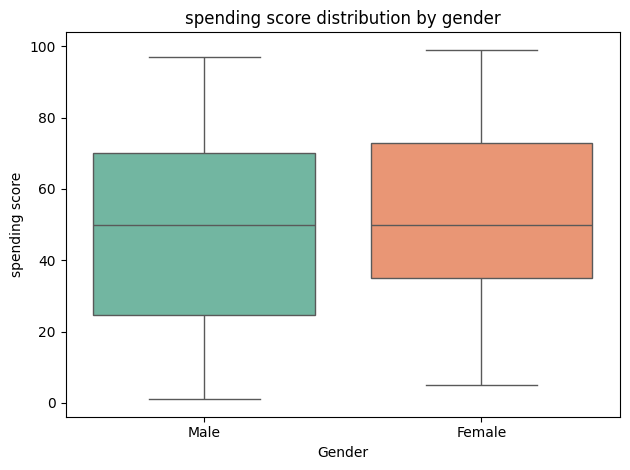

In [43]:
alpha = 0.05
if p_value < alpha:
    print(f" since p_value ({p_value}) is less than alpha ({alpha}), we reject the null hypothesis.")
    print(f"This suggests that there is a significant difference in spending scores between genders.")
else:
    print(f" since p_value ({p_value}) is greater than or equal to alpha ({alpha}), we fail to reject the null hypothesis.")
    print(" Conclusion:  there is no statistically significant difference in spending scores bewteen genders")

plt.figure()
sns.boxplot(data=df,x='Gender', y='Spending Score (1-100)',palette='Set2')
plt.xlabel('Gender')
plt.ylabel('spending score')
plt.title('spending score distribution by gender')
plt.tight_layout()
plt.show()

In [45]:
sample_mean = np.mean(df['Spending Score (1-100)'])
sample_size = len(df['Spending Score (1-100)'])
sample_std = np.std(df['Spending Score (1-100)'],ddof=1)
standard_error = sample_std /np.sqrt(sample_size)
print(f"sample mean:{sample_mean}")
print(f"sample size:{sample_size}")
print(f"sample standard deviation : {sample_std}")
print(f"standard error of the mean : {standard_error}")


sample mean:50.2
sample size:200
sample standard deviation : 25.823521668370173
standard error of the mean : 1.8259987285822297


SECTION 7: CONFIDENCE INTERVAL

In [46]:
confidence_level = 0.95
degrees_freedom = sample_size - 1
ci_lower, ci_upper = stats.t.interval(confidence_level, degrees_freedom , loc=sample_mean, scale=standard_error)
print(f"{confidence_level*100}% confidence interval for the mean spending score: ({ci_lower}, {ci_upper})")


95.0% confidence interval for the mean spending score: (46.5992098573812, 53.80079014261881)


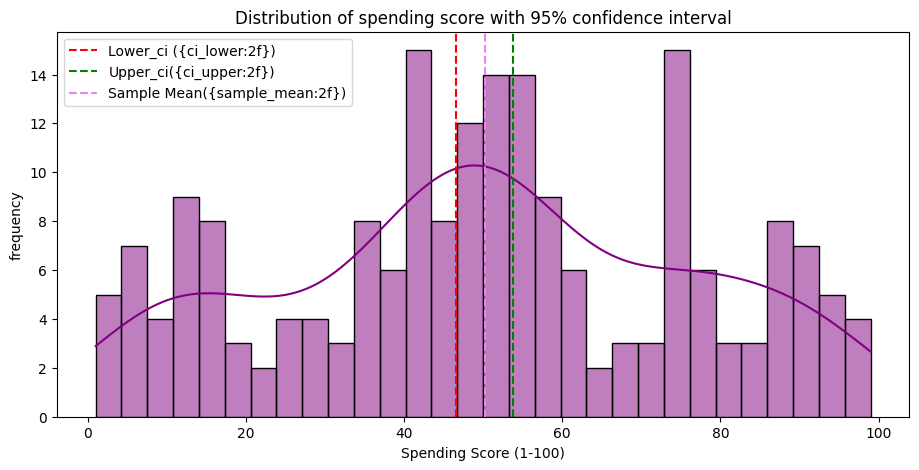

In [47]:
plt.figure(figsize=(11,5))
sns.histplot(df['Spending Score (1-100)'],bins=30, kde=True, color='purple')
plt.axvline(ci_lower, color='red', linestyle='--', label='Lower_ci ({ci_lower:2f})')
plt.axvline(ci_upper, color='green', linestyle='--', label='Upper_ci({ci_upper:2f})')
plt.axvline(sample_mean, color='violet', linestyle='--', label='Sample Mean({sample_mean:2f})')
plt.title('Distribution of spending score with 95% confidence interval')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('frequency')
plt.legend()
plt.show()

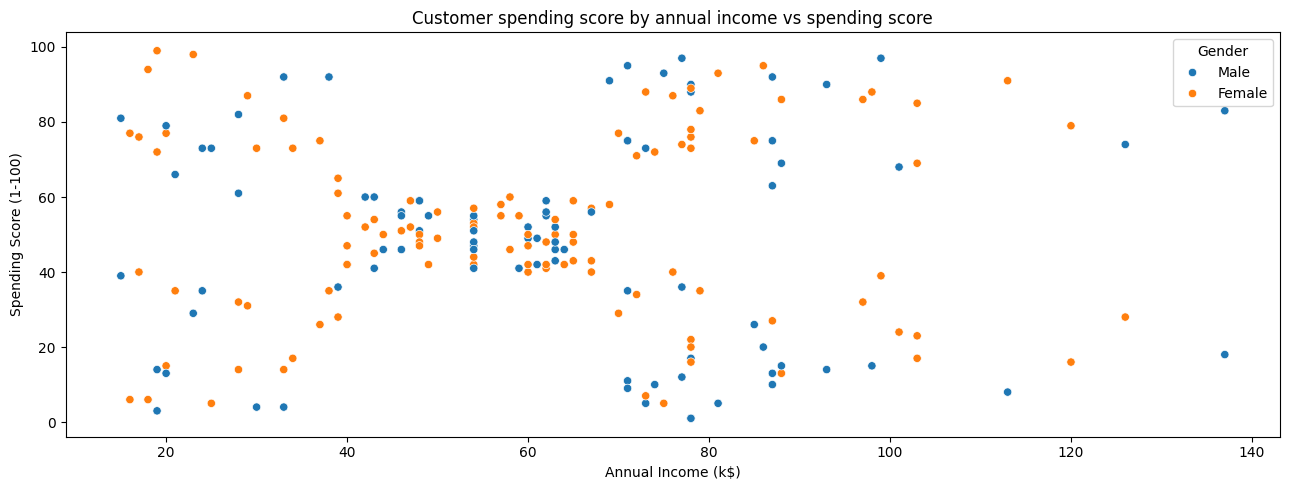

In [48]:
plt.figure(figsize=(13,5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df ,hue='Gender', color='teal')
plt.title("Customer spending score by annual income vs spending score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.tight_layout()
plt.show()


SECTION 8: BUSINESS INSIGHTS 

In [49]:
corr, p_value = stats.pearsonr(df['Annual Income (k$)'],df['Spending Score (1-100)'])
print(f"pearson correlation coefficient :{corr:.3f}(p_value:{p_value:.3f})")

pearson correlation coefficient :0.010(p_value:0.889)


C:\Users\AMIT KUMAR\AppData\Local\Temp\ipykernel_25076\3571041284.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Gender', y='Spending Score (1-100)',palette='pastel')


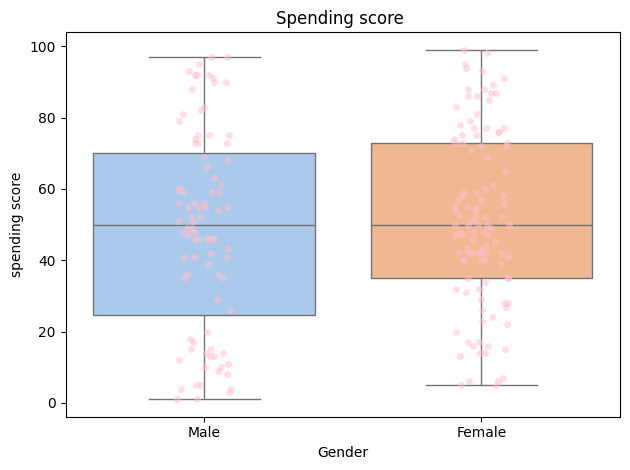

In [50]:
plt.figure()
sns.boxplot(data=df,x='Gender', y='Spending Score (1-100)',palette='pastel')
sns.stripplot(data=df,x='Gender', y='Spending Score (1-100)', color='pink',alpha=0.5,jitter=True)
plt.title("Spending score ")
plt.xlabel("Gender")
plt.ylabel("spending score")
plt.tight_layout()
plt.show()
              

In [52]:
male_spending = df[df['Gender'] == 'Male']['Spending Score (1-100)']
female_spending = df[df['Gender'] == 'Female']['Spending Score (1-100)']
t_stat, t_p_value = stats.ttest_ind(male_spending, female_spending, equal_var=False)
print(f"t-test results--- t-statistics:{t_stat:.2f},p_value:{t_p_value:.3f}")

      

t-test results--- t-statistics:-0.80,p_value:0.422
